# Simple Linear Regression:
Predicting Income After the Program Based on Income Before the Program

In [3]:
import pandas as pd
import statsmodels.api as sm

# Load data
df = pd.read_csv('data/cw1_data.csv')

# Define independent (X) and dependent (Y) variables
# We predict Income_After based on Income_Before
X = df['Income_Before']
Y = df['Income_After']

# Add a constant to the independent variable (for the intercept term)
X_with_const = sm.add_constant(X)

# Fit the simple linear regression model
model = sm.OLS(Y, X_with_const).fit()

# Print the summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Income_After   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     30.53
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           6.61e-06
Time:                        22:17:00   Log-Likelihood:                -79.012
No. Observations:                  30   AIC:                             162.0
Df Residuals:                      28   BIC:                             164.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.1038      3.516     -1.167

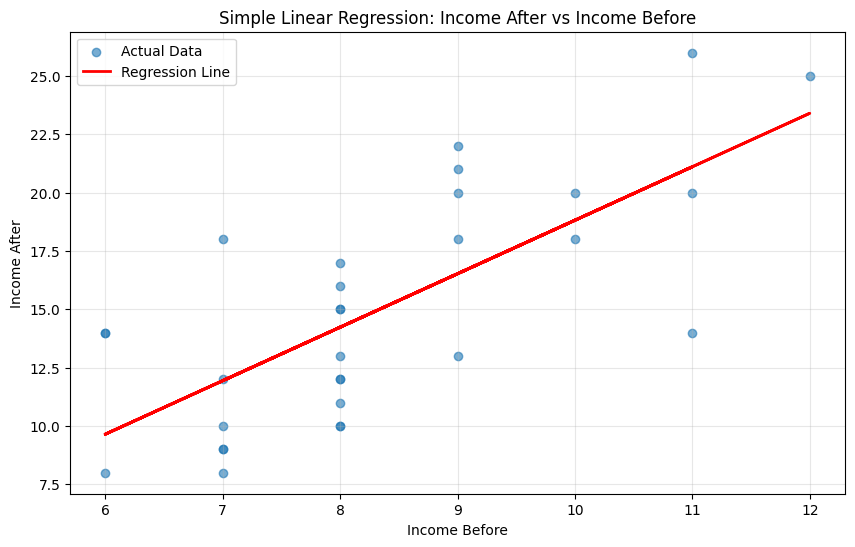

In [4]:
# Plot the regression
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.6, label='Actual Data')
plt.plot(X, model.predict(X_with_const), color='red', linewidth=2, label='Regression Line')
plt.xlabel('Income Before')
plt.ylabel('Income After')
plt.title('Simple Linear Regression: Income After vs Income Before')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Multiple Linear Regression:
Predicting Income After the Program Based on Multiple Factors

In [9]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('data/cw1_data.csv')

# Define initial independent variables and dependent variable
X = df[['Age', 'Marital_Status', 'Income_Before', 'Education', 'Gender', 'Household_Members', 'Program_Status']]
Y = df['Income_After']


# Function for backward elimination based on p-values
def backward_elimination(x, y, sl=0.05):
    """
    Perform backward elimination for feature selection based on p-values.

    Parameters
    ----------
    x : pandas.DataFrame or array-like
        Feature matrix containing the candidate predictor variables.
    y : pandas.Series or array-like
        Target variable to be predicted.
    sl : float, optional
        Significance level (p-value threshold) used to decide whether a
        feature should be removed. Features with p-values greater than
        this threshold are iteratively eliminated. Default is 0.05.

    Returns
    -------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        The final fitted OLS model after backward elimination.
    selected_columns : pandas.Index
        The names of the features (including the constant, if kept)
        that remain in the model after backward elimination.
    """
    # Add constant initially
    x_const = sm.add_constant(x, has_constant='add')
    while True:
        model = sm.OLS(y, x_const).fit()  # Fit the Ordinary Least Squares model
        pvals = model.pvalues  # Get the p-values for each variable
        max_pval = pvals.max()  # Find the variable with the highest p-value
        if max_pval > sl:  # If the variable is insignificant (p-value above the significance level)
            # Find the variable with the highest p-value
            max_pval_idx = pvals.idxmax()  # Find the index of the variable to drop
            if max_pval_idx == 'const':
                # If the constant has the highest p-value, check the variables only.
                pvals_no_const = pvals.drop('const')  # Drop the constant from the p-values
                # If dropping 'const' leaves no other variables, there are no predictors
                # left to eliminate. Stop and keep the current (constant-only) model.
                if pvals_no_const.empty:  # Check if there are no other variables left
                    break
                max_pval_no_const = pvals_no_const.max()  # Find the variable with the highest p-value
                if max_pval_no_const > sl:  # If the highest p-value among the variables is still above the threshold, drop it.
                    max_pval_idx = pvals_no_const.idxmax()  # Find the index of the variable to drop
                else:
                    # Only the constant is insignificant; stop elimination.
                    break
            x_const = x_const.drop(max_pval_idx, axis=1)  # Drop the variable with the highest p-value from the model
        else:
            break
    return model, x_const.columns  # Return the final model and selected columns


final_model, final_columns = backward_elimination(X, Y)  # Perform backward elimination

print("Variables selected by backward elimination:", final_columns.tolist())
print(final_model.summary())

Variables selected by backward elimination: ['const', 'Income_Before', 'Program_Status']
                            OLS Regression Results                            
Dep. Variable:           Income_After   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     61.19
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           9.34e-11
Time:                        22:27:15   Log-Likelihood:                -64.411
No. Observations:                  30   AIC:                             134.8
Df Residuals:                      27   BIC:                             139.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

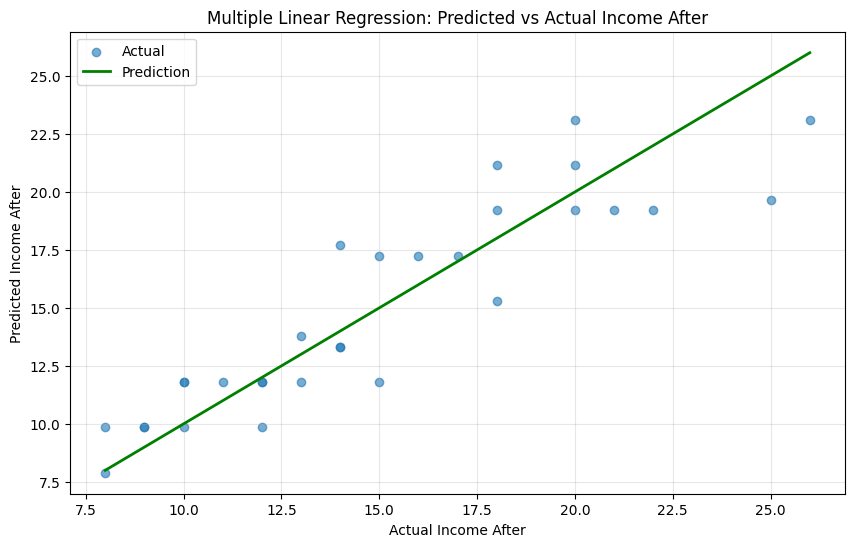

In [12]:
# Plot the multiple linear regression
X_final = sm.add_constant(df[final_columns.drop('const')])
predictions = final_model.predict(X_final)

plt.figure(figsize=(10, 6))
plt.scatter(Y, predictions, alpha=0.6, label='Actual')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], color='green', linewidth=2, label='Prediction')
plt.xlabel('Actual Income After')
plt.ylabel('Predicted Income After')
plt.title('Multiple Linear Regression: Predicted vs Actual Income After')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
